# 00 — Data Exploration & Method Visualisation

Loads a single `.pkl` data file and produces diagnostic figures:

1. **Event frequency map** — where do extreme events occur?
2. **GMT ↔ temperature relationships** — for the best-attributed event
3. **Correctly attributed event** — distributions, SLP analogue map, local Ridge weight map
4. **Type I error example** — same diagnostics for a spuriously attributed counterfactual event

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/homerdurand/Attribution_challenge_2026/blob/main/00_exploration.ipynb)

**Set the paths in the CONFIG cell, then Run All.**

In [1]:
import sys, os, pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# SRC_PATH = '/content/drive/MyDrive/ellis-attribution/src'
SRC_PATH = 'src'

sys.path.insert(0, SRC_PATH)

# ── Data utilities ────────────────────────────────────────────────
from data_utils import extract_local_slp, get_window

# ── Attribution helpers ───────────────────────────────────────────
from attribution import (
    compute_pn,
    run_thermo_ml,
    run_dyn_adj_local,
    thermo_cf,
    pn_gaussian,
)

# ── Visualisation ─────────────────────────────────────────────────
from visualization import (
    plot_event_frequency_map,
    plot_gmt_tas,
    plot_distributions,
    plot_analogue_maps,
    plot_local_ridge_weights,
)

# ── sklearn (only needed for build_cf_dict below) ─────────────────
from sklearn.linear_model import RidgeCV


/home/homer/anaconda3/envs/attribution_chanllenge/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# ================================================================
#  CONFIG  —  edit here
# ================================================================
# PKL_PATH    = '/content/drive/MyDrive/ellis-attribution/data/extracted_tasmax_nmem10_start1980_p99.9.pkl'
path_extracted = '/home/homer/Documents/Research/Data/attribution_evaluation_data/extracted/'
PKL_PATH    = path_extracted + 'extracted_tasmax_nmem10_start1980_p99.pkl'

# FIGURES_DIR = '/content/drive/MyDrive/ellis-attribution/figures'
FIGURES_DIR = 'figures'

MEMBER_IDX  = 0

# Analogue parameters
N_ANALOGUES       = 10
N_YEARS_POOL      = 20
ANALOGUE_HALF_DEG = 15.0   # box for KNN analogue search  -> 50x50 deg
DYNADJ_HALF_DEG   = 15.0   # box for local Ridge DynAdj   -> 80x80 deg

# Ridge regularisation
RIDGE_ALPHAS = np.logspace(-3, 8, 20)

# PN time window (months)
WINDOW_BEFORE = 72
WINDOW_AFTER  = 12

# GMT plot period
GMT_START_YEAR = 1980
GMT_END_YEAR   = 2014

# Target year for 'recent event' selection in GMT plot
TARGET_YEAR = 2010
# ================================================================

os.makedirs(FIGURES_DIR, exist_ok=True)
with open(PKL_PATH, 'rb') as fh:
    full_data = pickle.load(fh)

d = full_data[MEMBER_IDX]
print(f'Member   : {d["member"]}')
print(f'Events   : {d["f_tas"].shape[1]}')
print(f'Timesteps: {len(d["times"])}')
print(f'SLP grid : {d["f_slp"].shape}')


Member   : r1i1p1f1
Events   : 461
Timesteps: 1980
SLP grid : (1980, 143, 144)


## 1. Event frequency map
Pixel-wise count of timesteps belonging to an extreme event (factual run), overlaid with event barycentres pooled across all members.

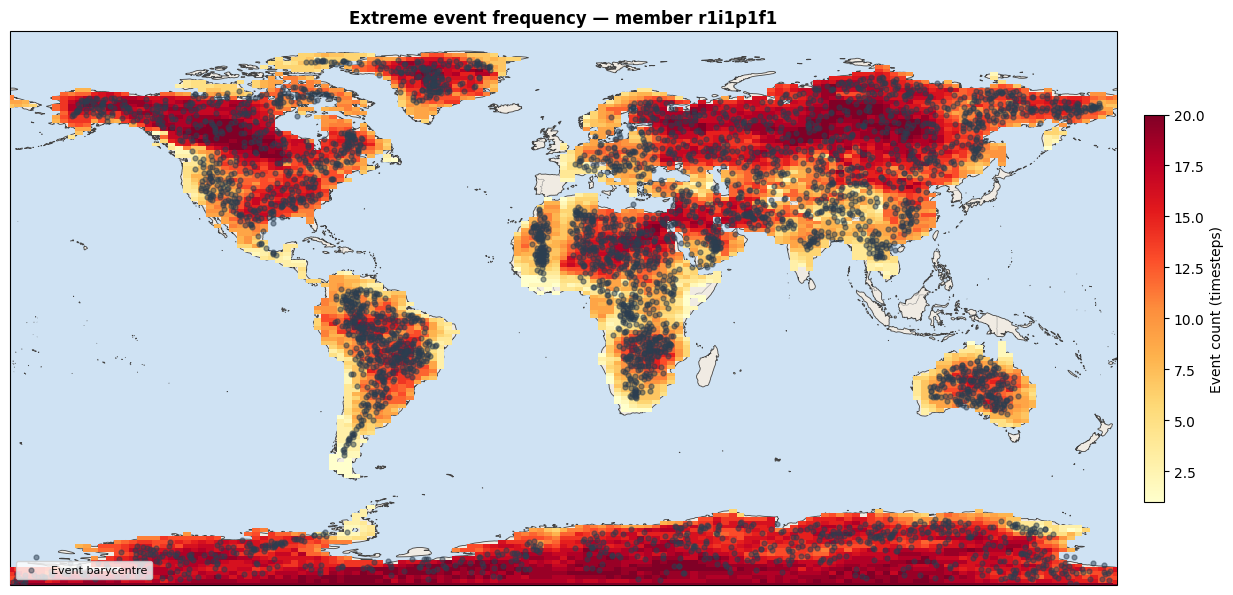

Saved -> figures/freq_map.png


In [3]:
plot_event_frequency_map(
    full_data, member_idx=MEMBER_IDX,
    save_path=os.path.join(FIGURES_DIR, 'freq_map.png'))


## Auto-select events of interest

Scores every event with `pn_gaussian` (thermodynamic CF) and picks:
- **Factual** event closest to `TARGET_YEAR` among those with high PN → used for GMT plot + 'correct attribution' diagnostics
- **Counterfactual** event with highest spurious PN → Type I error diagnostics


In [4]:
gmt   = d['gmt4_f']
times_dt = pd.to_datetime(d['times'])
n_ev  = d['f_tas'].shape[1]
pn_f  = np.zeros(n_ev)
pn_cf = np.zeros(n_ev)

for e in range(n_ev):
    for is_f in (True, False):
        tas_arr = d['f_tas'] if is_f else d['c_tas']
        val_arr = d['f_tas_vals'] if is_f else d['c_tas_vals']
        t_obs, t0, t1 = get_window(d, e, is_f, WINDOW_BEFORE, WINDOW_AFTER)
        tas_e = tas_arr[:, e]
        cf    = thermo_cf(tas_e, gmt)
        pn    = pn_gaussian(tas_e[t0:t1], cf[t0:t1], val_arr[e])
        if is_f:
            pn_f[e]  = pn
        else:
            pn_cf[e] = pn

# Best factual event: highest PN among those occurring close to TARGET_YEAR
factual_years = np.array([
    times_dt[d['idx_f'][e]].year for e in range(n_ev)
])
# Score = PN weighted by proximity to TARGET_YEAR
year_score  = np.exp(-((factual_years - TARGET_YEAR) ** 2) / (5 ** 2))  # sigma=5yr
combined    = pn_f * year_score
e_fact      = int(np.argmax(combined))

# Worst Type I: highest spurious PN in counterfactual run
e_type1 = int(np.argmax(pn_cf))

print(f'Best factual event    : {e_fact:3d}  year={factual_years[e_fact]}  PN={pn_f[e_fact]:.3f}')
print(f'Worst Type I error    : {e_type1:3d}  PN={pn_cf[e_type1]:.3f}')


Best factual event    : 343  year=2010  PN=1.000
Worst Type I error    : 423  PN=0.466


## 2. GMT ↔ temperature relationships
Best-attributed factual event near `TARGET_YEAR`, period restricted to `GMT_START_YEAR`–`GMT_END_YEAR`.

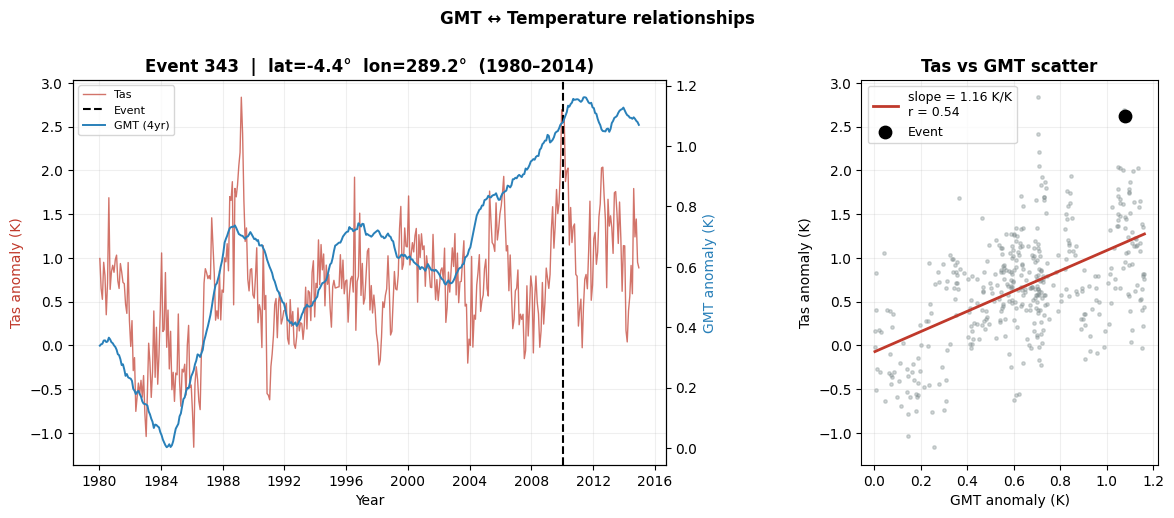

Saved -> figures/gmt_relationships.png


In [5]:
plot_gmt_tas(
    d, e_fact,
    start_year=GMT_START_YEAR, end_year=GMT_END_YEAR,
    save_path=os.path.join(FIGURES_DIR, 'gmt_relationships.png'))


## Helper: build_cf_dict
Constructs counterfactual series and fitted objects for each method.
Calls `run_thermo_ml` and `run_dyn_adj_local` from `src/attribution.py`.

In [6]:
def build_cf_dict(d, e_idx, is_factual):
    """
    Returns (cf_dict, extras):
      cf_dict : {method_name: counterfactual_array (T,)}
      extras  : fitted objects needed for weight / analogue plots
    """
    tas_run = d['f_tas'][:, e_idx] if is_factual else d['c_tas'][:, e_idx]
    slp_run = d['f_slp'] if is_factual else d['c_slp']
    ev_lat, ev_lon = d['location'][e_idx]
    gmt_f   = d['gmt4_f']
    gmt_c   = np.full_like(gmt_f, gmt_f[0])

    t_obs, t0, t1 = get_window(d, e_idx, is_factual, WINDOW_BEFORE, WINDOW_AFTER)

    # Ensemble ground truth pools
    pool_f = np.concatenate([
        m['f_tas'][t0:t1, e_idx] for m in full_data
        if e_idx < m['f_tas'].shape[1]])
    pool_c = np.concatenate([
        m['c_tas'][t0:t1, e_idx] for m in full_data
        if e_idx < m['c_tas'].shape[1]])

    # Thermodynamic (calls src/attribution.py)
    cf_thermo = thermo_cf(tas_run, gmt_f)

    # Local Ridge — no PCA, direct fit on the flattened box
    slp_local = extract_local_slp(
        slp_run, d['slp_lat'], d['slp_lon'], ev_lat, ev_lon, DYNADJ_HALF_DEG)
    ridge_l  = RidgeCV(alphas=RIDGE_ALPHAS).fit(slp_local, tas_run)
    cf_local = ridge_l.predict(slp_local)

    cf_dict = {
        'Thermo ML':    cf_thermo,
        'DynAdj Local': cf_local,
    }
    extras = {
        'ridge_l':   ridge_l,
        'slp_local': slp_local,
        'pool_f':    pool_f,
        'pool_c':    pool_c,
        'tas_run':   tas_run,
    }
    return cf_dict, extras


## 3. Correctly attributed event (factual run)
Best-attributed factual event: distributions, analogue SLP maps, local Ridge weights.

In [7]:
e_idx = e_fact
ev_lat, ev_lon = d['location'][e_idx]
t_obs, t0, t1  = get_window(d, e_idx, True, WINDOW_BEFORE, WINDOW_AFTER)
val            = d['f_tas_vals'][e_idx]
print(f'Event {e_idx}: lat={ev_lat:.1f}  lon={ev_lon:.1f}  PN={pn_f[e_idx]:.3f}')

cf_dict, extras = build_cf_dict(d, e_idx, is_factual=True)


Event 343: lat=-4.4  lon=289.2  PN=1.000


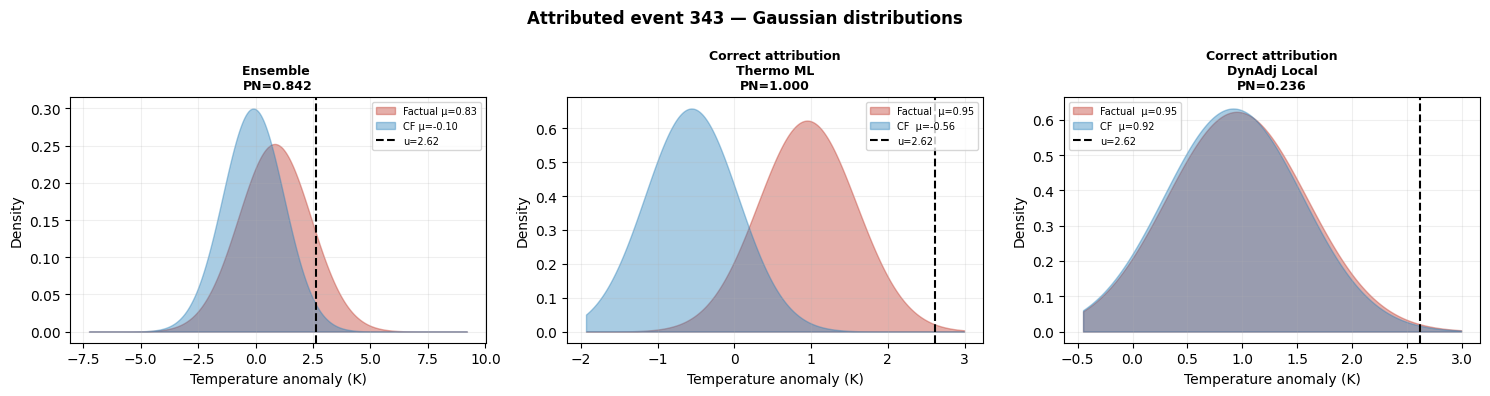

In [8]:
# ── Distributions (Ensemble + each method) ────────────────────────
from scipy.stats import norm

pool_f, pool_c = extras['pool_f'], extras['pool_c']
all_methods    = {'Ensemble ': None, **cf_dict}
fig, axes = plt.subplots(1, len(all_methods), figsize=(5 * len(all_methods), 4))
if len(all_methods) == 1: axes = [axes]

# Ensemble panel
x = np.linspace(min(pool_f.min(), pool_c.min()) - 0.3,
                max(pool_f.max(), pool_c.max()) + 0.3, 300)
mu_f, s_f   = norm.fit(pool_f);  mu_cf, s_cf = norm.fit(pool_c)
p_f  = norm.sf(val, mu_f, s_f);  p_cf = norm.sf(val, mu_cf, s_cf)
pn_ens = max(0.0, 1.0 - p_cf / p_f) if p_f > 0 else 0.0
axes[0].fill_between(x, norm.pdf(x, mu_f,  s_f),  alpha=0.4, color='#c0392b', label=f'Factual μ={mu_f:.2f}')
axes[0].fill_between(x, norm.pdf(x, mu_cf, s_cf), alpha=0.4, color='#2980b9', label=f'CF μ={mu_cf:.2f}')
axes[0].axvline(val, color='black', lw=1.5, ls='--', label=f'u={val:.2f}')
axes[0].set_title(f'Ensemble \nPN={pn_ens:.3f}', fontsize=9, fontweight='bold')
axes[0].legend(fontsize=7); axes[0].grid(True, alpha=0.2)
axes[0].set_xlabel('Temperature anomaly (K)'); axes[0].set_ylabel('Density')

# Method panels — calls src/visualization.py
plot_distributions(axes[1:], d, e_idx, True, cf_dict, 'Correct attribution',
                   WINDOW_BEFORE, WINDOW_AFTER)

fig.suptitle(f'Attributed event {e_idx} — Gaussian distributions',
             fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'correct_distributions.png'), dpi=200, bbox_inches='tight')
plt.show()


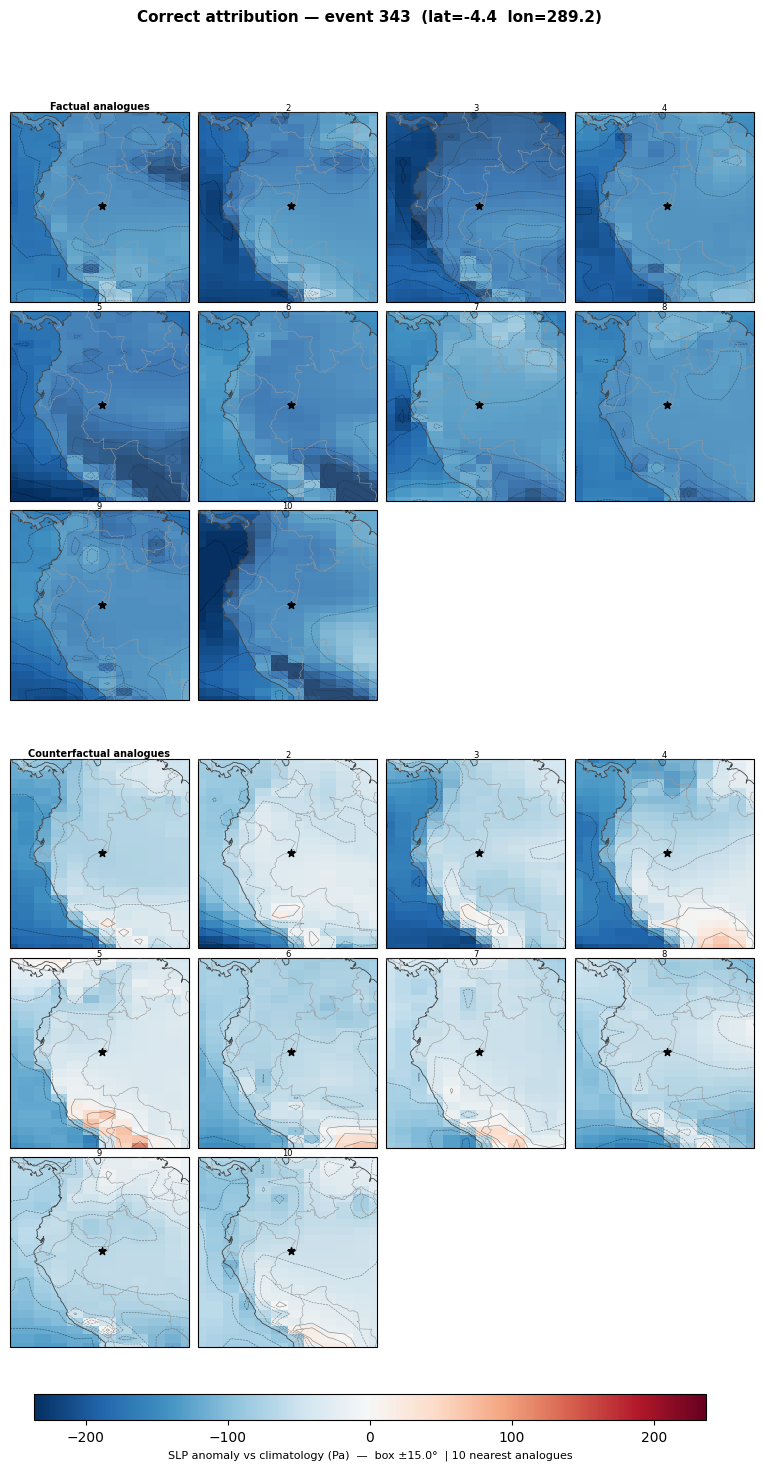

Saved -> figures/correct_analogue_slp.png


In [9]:
# ── Analogue maps — calls src/visualization.py ────────────────────
plot_analogue_maps(
    d, e_idx,
    suptitle=f'Correct attribution — event {e_idx}  (lat={ev_lat:.1f}  lon={ev_lon:.1f})',
    save_path=os.path.join(FIGURES_DIR, 'correct_analogue_slp.png'),
    n_analogues=N_ANALOGUES, n_years_pool=N_YEARS_POOL,
    half_width_deg=ANALOGUE_HALF_DEG,
    window_before=WINDOW_BEFORE, window_after=WINDOW_AFTER)


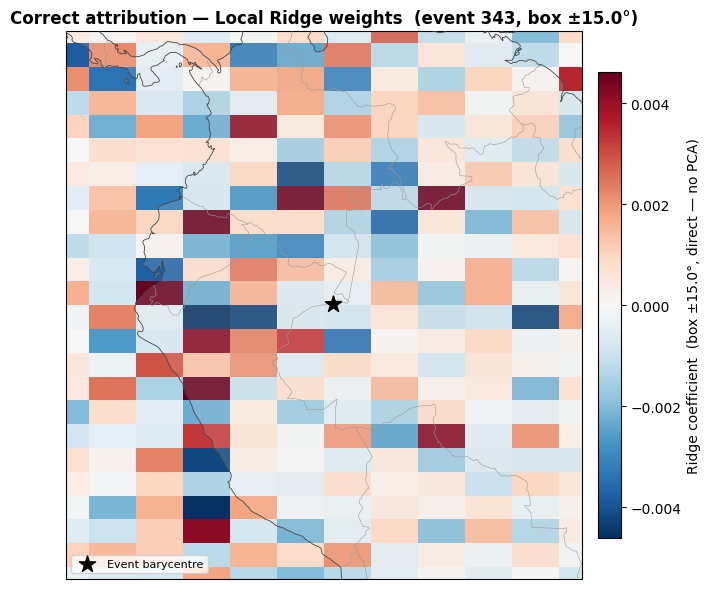

Saved -> figures/correct_ridge_weights.png


In [10]:
# ── Ridge weight map — calls src/visualization.py ─────────────────
plot_local_ridge_weights(
    d, e_idx, extras['ridge_l'].coef_,
    suptitle=f'Correct attribution — Local Ridge weights  (event {e_idx}, box ±{DYNADJ_HALF_DEG}°)',
    save_path=os.path.join(FIGURES_DIR, 'correct_ridge_weights.png'),
    half_width_deg=DYNADJ_HALF_DEG)


## 4. Type I error — spuriously attributed counterfactual event
Counterfactual event with the highest spurious PN: same three diagnostics.

In [11]:
e_idx_cf = e_type1
ev_lat_cf, ev_lon_cf = d['location'][e_idx_cf]
t_obs_cf, t0c, t1c   = get_window(d, e_idx_cf, False, WINDOW_BEFORE, WINDOW_AFTER)
val_cf               = d['c_tas_vals'][e_idx_cf]
print(f'Event {e_idx_cf}: lat={ev_lat_cf:.1f}  lon={ev_lon_cf:.1f}  spurious PN={pn_cf[e_idx_cf]:.3f}')

cf_dict_cf, extras_cf = build_cf_dict(d, e_idx_cf, is_factual=False)


Event 423: lat=34.1  lon=65.0  spurious PN=0.466


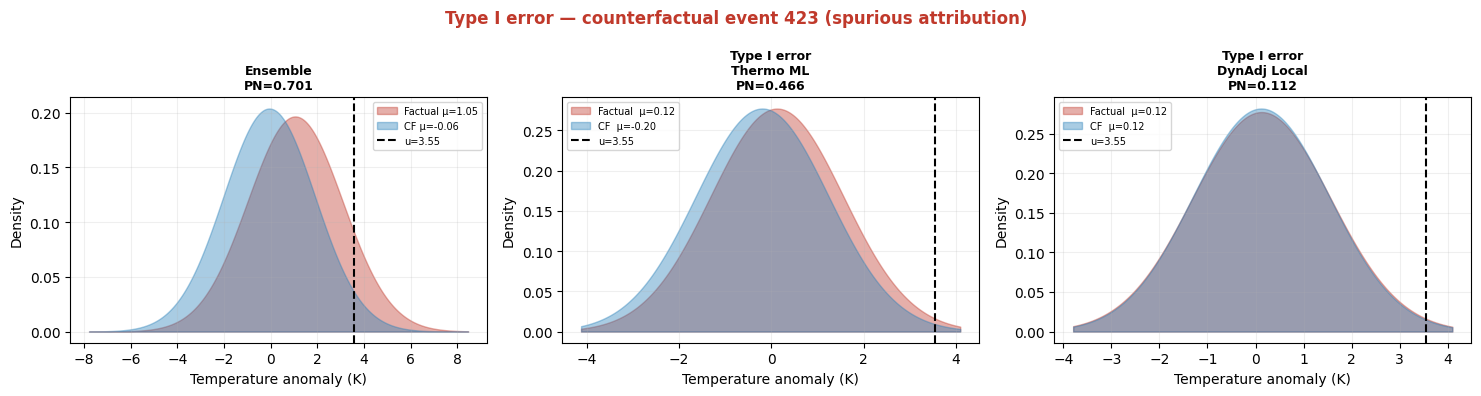

In [12]:
# ── Distributions ─────────────────────────────────────────────────
pool_f_cf, pool_c_cf = extras_cf['pool_f'], extras_cf['pool_c']
all_methods_cf = {'Ensemble': None, **cf_dict_cf}
fig2, axes2 = plt.subplots(1, len(all_methods_cf), figsize=(5 * len(all_methods_cf), 4))
if len(all_methods_cf) == 1: axes2 = [axes2]

x2 = np.linspace(min(pool_f_cf.min(), pool_c_cf.min()) - 0.3,
                 max(pool_f_cf.max(), pool_c_cf.max()) + 0.3, 300)
mu_f2, s_f2   = norm.fit(pool_f_cf);  mu_cf2, s_cf2 = norm.fit(pool_c_cf)
p_f2  = norm.sf(val_cf, mu_f2, s_f2); p_cf2 = norm.sf(val_cf, mu_cf2, s_cf2)
pn_ens2 = max(0.0, 1.0 - p_cf2 / p_f2) if p_f2 > 0 else 0.0
axes2[0].fill_between(x2, norm.pdf(x2, mu_f2,  s_f2),  alpha=0.4, color='#c0392b', label=f'Factual μ={mu_f2:.2f}')
axes2[0].fill_between(x2, norm.pdf(x2, mu_cf2, s_cf2), alpha=0.4, color='#2980b9', label=f'CF μ={mu_cf2:.2f}')
axes2[0].axvline(val_cf, color='black', lw=1.5, ls='--', label=f'u={val_cf:.2f}')
axes2[0].set_title(f'Ensemble\nPN={pn_ens2:.3f}', fontsize=9, fontweight='bold')
axes2[0].legend(fontsize=7); axes2[0].grid(True, alpha=0.2)
axes2[0].set_xlabel('Temperature anomaly (K)'); axes2[0].set_ylabel('Density')

plot_distributions(axes2[1:], d, e_idx_cf, False, cf_dict_cf, 'Type I error',
                   WINDOW_BEFORE, WINDOW_AFTER)

fig2.suptitle(f'Type I error — counterfactual event {e_idx_cf} (spurious attribution)',
              fontweight='bold', color='#c0392b')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'type1_distributions.png'), dpi=200, bbox_inches='tight')
plt.show()


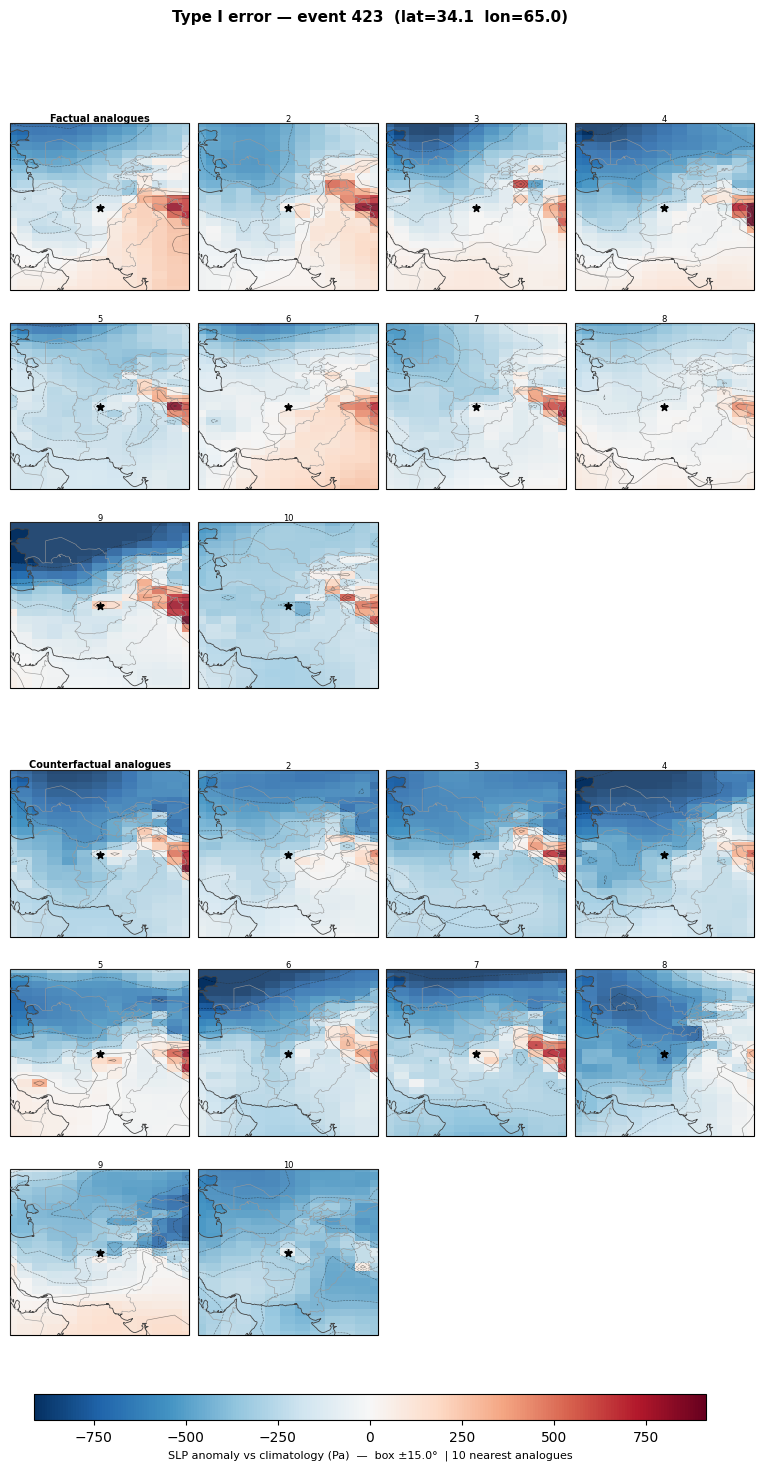

Saved -> figures/type1_analogue_slp.png


In [13]:
plot_analogue_maps(
    d, e_idx_cf,
    suptitle=f'Type I error — event {e_idx_cf}  (lat={ev_lat_cf:.1f}  lon={ev_lon_cf:.1f})',
    save_path=os.path.join(FIGURES_DIR, 'type1_analogue_slp.png'),
    n_analogues=N_ANALOGUES, n_years_pool=N_YEARS_POOL,
    half_width_deg=ANALOGUE_HALF_DEG,
    window_before=WINDOW_BEFORE, window_after=WINDOW_AFTER)


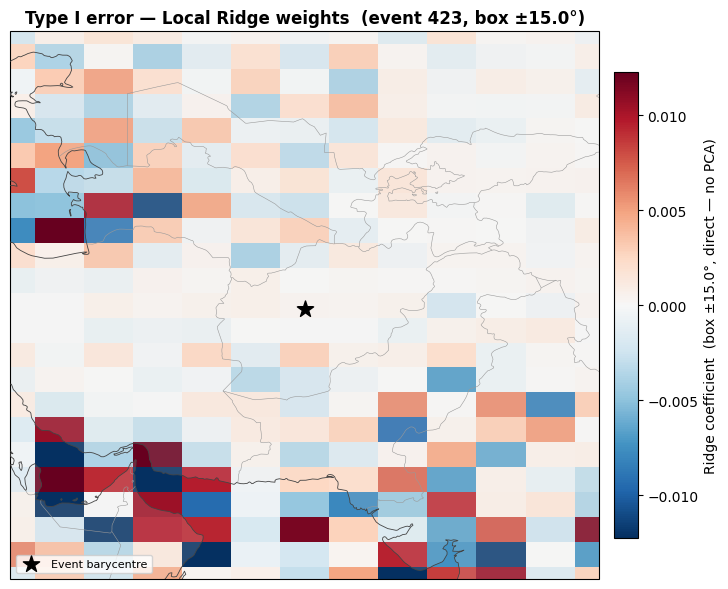

Saved -> figures/type1_ridge_weights.png


In [14]:
plot_local_ridge_weights(
    d, e_idx_cf, extras_cf['ridge_l'].coef_,
    suptitle=f'Type I error — Local Ridge weights  (event {e_idx_cf}, box ±{DYNADJ_HALF_DEG}°)',
    save_path=os.path.join(FIGURES_DIR, 'type1_ridge_weights.png'),
    half_width_deg=DYNADJ_HALF_DEG)
